In [2]:
%load_ext autoreload

In [141]:
%autoreload 2
%aimport sog1_helpers

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import protfasta

from Bio import Phylo
from Bio import AlignIO
import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

#plt.rcParams['text.usetex'] = True

plt.rcParams['ps.fonttype'] = 42
plt.rcParams["font.family"] = "Helvetica" #somethings this one doesnt work
plt.rcParams['pdf.fonttype'] = 42

activity_col = "Activity_S3_1"

# 1. Generating alignment

In [142]:
# Reading in full sequences
nac_seqs = pd.read_csv("../data/nac_family.csv", sep = "\t", header = None)
nac_seqs["name"] = "NAC" + nac_seqs[0].str.split("|").str[0]
nac_seqs

,0,1,name
0,006|Q9LR74|,MKILPVGSRFCPTDLGLVRLYLRNKVERNQSSFITTMDIHQDYPWL...,NAC006
1,012|Q9LPI7|,MADNKVNLSINGQSKVPPGFRFHPTEEELLHYYLRKKVNSQKIDLD...,NAC012
2,016|A4FVP|,MVDSSRDSCFKAGKFSAPGFRFHPTDEELVVYYLKRKICCKKLRVN...,NAC016
3,019|Q9C932|,MGIQETDPLTQLSLPPGFRFYPTDEELMVQYLCRKAAGYDFSLQLI...,NAC019
4,042|Q9SK55|JUNGBRUNNEN|,MSGEGNLGKDHEEENEAPLPGFRFHPTDEELLGYYLRRKVENKTIK...,NAC042
5,044|F4J4R5|,MARAWIVDGRGIAAKVKNASLSSALQIQDCGAHIKCPNCTYRIDNS...,NAC044
6,062|Q9SCK6|,MNQNLHVLSMDSLPVGLRFRPTDEELIRYYLRRKINGHDDDVKAIR...,NAC062
7,067|O82593|,MMKDPTGYRFSPTGEEVINHYLKNKILGKTWLVDEAISEINILNHK...,NAC067
8,071|O49697|,MGSSCLPPGFRFHPTDEELIGYYLSRKIEGLEIELEVIPVIDLYKF...,NAC071
9,076|O65508|,MESVDQSCSVPPGFRFHPTDEELVGYYLRKKVASQKIDLDVIRDID...,NAC076


In [143]:
# Add SOG1
wt_seq = "".join(pd.read_csv("../data/Sog1_AA_features.csv")["aa"])
wt_seq

'MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVIDNSDVVDDWPGLPRGVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPTVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKAYSTGTRKRRKIHDDDFGDVRWHKTGRTKPVVLDGVQRGCKKIMVLYGGKAVKTNWVMHQYHLGIEEDEKEGDYVVSKIFYQQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVTPKLATPEPRNAVRICSDSHIASDYVTPSDYVSAHEVSLAETSEVMCMEDEVQSIQPNHERPSSGPELEHGLENGAKEMLDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLVEALSLCDDLLGSQDREENTNSGSLKDKQPCIADYAHLGPEDFKRDLEECQKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTGKTD'

In [144]:
nac_seqs.loc[15] = ["008|Q6NQK2|", wt_seq, "SOG1"]
nac_seqs

,0,1,name
0,006|Q9LR74|,MKILPVGSRFCPTDLGLVRLYLRNKVERNQSSFITTMDIHQDYPWL...,NAC006
1,012|Q9LPI7|,MADNKVNLSINGQSKVPPGFRFHPTEEELLHYYLRKKVNSQKIDLD...,NAC012
2,016|A4FVP|,MVDSSRDSCFKAGKFSAPGFRFHPTDEELVVYYLKRKICCKKLRVN...,NAC016
3,019|Q9C932|,MGIQETDPLTQLSLPPGFRFYPTDEELMVQYLCRKAAGYDFSLQLI...,NAC019
4,042|Q9SK55|JUNGBRUNNEN|,MSGEGNLGKDHEEENEAPLPGFRFHPTDEELLGYYLRRKVENKTIK...,NAC042
5,044|F4J4R5|,MARAWIVDGRGIAAKVKNASLSSALQIQDCGAHIKCPNCTYRIDNS...,NAC044
6,062|Q9SCK6|,MNQNLHVLSMDSLPVGLRFRPTDEELIRYYLRRKINGHDDDVKAIR...,NAC062
7,067|O82593|,MMKDPTGYRFSPTGEEVINHYLKNKILGKTWLVDEAISEINILNHK...,NAC067
8,071|O49697|,MGSSCLPPGFRFHPTDEELIGYYLSRKIEGLEIELEVIPVIDLYKF...,NAC071
9,076|O65508|,MESVDQSCSVPPGFRFHPTDEELVGYYLRKKVASQKIDLDVIRDID...,NAC076


In [145]:
# Preparing to align
protfasta.write_fasta(dict(zip(nac_seqs["name"], nac_seqs[1])), "../data/nac_seqs.fasta")

In [146]:
! mafft --auto --quiet ../data/nac_seqs.fasta > ../data/nac_seqs_aligned.fasta

In [147]:
#! FastTree ../data/nac_seqs_aligned.fasta > ../data/nac_seqs_aligned

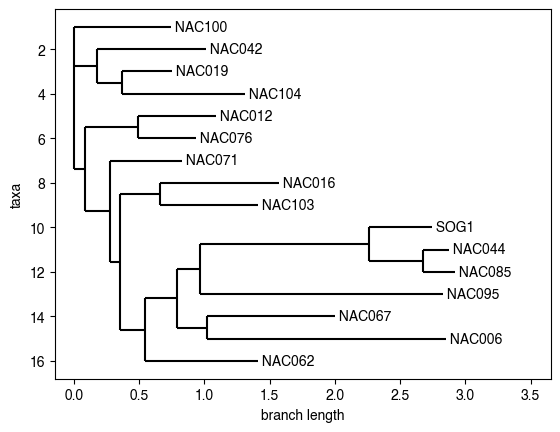

In [148]:
AD_tree = Phylo.read("../data/nac_seqs_aligned", "newick")
Phylo.draw(AD_tree, do_show=False, show_confidence=False)  # Pass axes to the draw function

In [149]:
alignment = AlignIO.read("../data/nac_seqs_aligned.fasta", "fasta")
print(alignment)

Alignment with 16 rows and 757 columns
--------------------------------------------...--- NAC006
MA------------------------------------------...--- NAC012
MV------------------------------------------...LLS NAC016
MG------------------------------------------...--- NAC019
MSG-----------------------------------------...--- NAC042
MA---RAWIVDGRGIAAKVKNASLSSALQ--IQDCGAHIKCPNC...--- NAC044
MN------------------------------------------...AVS NAC062
M-------------------------------------------...--- NAC067
--------------------------------------------...--- NAC071
ME------------------------------------------...LHV NAC076
MKTLHRTWIVDGPWISRNVKNASLSSALQ--IKDCGAYINCFNC...--- NAC085
MG------------------------------------------...--- NAC095
ME------------------------------------------...--- NAC100
--------------------------------------------...--- NAC103
--------------------------------------------...--- NAC104
MAG--RSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCPKC...--- SOG1


# 2. Reading in activities

In [150]:
basic_tiles = sog1_helpers.return_activities("Basic", pos_regex = "")
basic_tiles = basic_tiles[~basic_tiles["Description"].str.contains("_")]
basic_tiles["name"] = basic_tiles["Other"].str.split("_").str[0]
basic_tiles["name"] = basic_tiles["name"].str.replace("SOG1", "")
basic_tiles["name"] = basic_tiles["name"].str.strip()
basic_tiles["search_term"] = basic_tiles["Description"].str.split(".").str[0] + "\."
basic_tiles

,Start,End,Description,Other,tile,Activity_S3_1,Activity_S3_2,lib2_avg,name,search_term
0,1,40,Basic6.1,Q9LR74,MKILPVGSRFCPTDLGLVRLYLRNKVERNQSSFITTMDIH,586.178097,NaN,586.178097,Q9LR74,Basic6\.
1,11,50,Basic6.2,Q9LR74,CPTDLGLVRLYLRNKVERNQSSFITTMDIHQDYPWLLPHV,2211.966071,2343.749322,2277.857696,Q9LR74,Basic6\.
2,21,60,Basic6.3,Q9LR74,YLRNKVERNQSSFITTMDIHQDYPWLLPHVNNPLFNNNEW,NaN,NaN,NaN,Q9LR74,Basic6\.
3,31,70,Basic6.4,Q9LR74,SSFITTMDIHQDYPWLLPHVNNPLFNNNEWYYFVPLTERG,573.518390,599.219717,586.369054,Q9LR74,Basic6\.
4,41,80,Basic6.5,Q9LR74,QDYPWLLPHVNNPLFNNNEWYYFVPLTERGGKILSVHRKV,315.722705,392.863309,354.293007,Q9LR74,Basic6\.
...,...,...,...,...,...,...,...,...,...,...
3012,371,410,BasicArTh.38,Q6NQK2,GSQDREENTNSGSLKDKQPCIADYAHLGPEDFKRDLEECQ,601.553077,3400.972046,2001.262561,Q6NQK2,BasicArTh\.
3013,381,420,BasicArTh.39,Q6NQK2,SGSLKDKQPCIADYAHLGPEDFKRDLEECQKIVLDPSNIE,508.338058,1512.228706,1010.283382,Q6NQK2,BasicArTh\.
3014,391,430,BasicArTh.40,Q6NQK2,IADYAHLGPEDFKRDLEECQKIVLDPSNIELDTPPEFRLS,1960.462356,1783.792784,1872.127570,Q6NQK2,BasicArTh\.
3015,401,440,BasicArTh.41,Q6NQK2,DFKRDLEECQKIVLDPSNIELDTPPEFRLSQLEFGSQDSF,2216.350444,2335.951103,2276.150773,Q6NQK2,BasicArTh\.


In [151]:
nac_seqs["uniprotID"] = nac_seqs[0].str.split("|").str[1]
nac_seqs

,0,1,name,uniprotID
0,006|Q9LR74|,MKILPVGSRFCPTDLGLVRLYLRNKVERNQSSFITTMDIHQDYPWL...,NAC006,Q9LR74
1,012|Q9LPI7|,MADNKVNLSINGQSKVPPGFRFHPTEEELLHYYLRKKVNSQKIDLD...,NAC012,Q9LPI7
2,016|A4FVP|,MVDSSRDSCFKAGKFSAPGFRFHPTDEELVVYYLKRKICCKKLRVN...,NAC016,A4FVP
3,019|Q9C932|,MGIQETDPLTQLSLPPGFRFYPTDEELMVQYLCRKAAGYDFSLQLI...,NAC019,Q9C932
4,042|Q9SK55|JUNGBRUNNEN|,MSGEGNLGKDHEEENEAPLPGFRFHPTDEELLGYYLRRKVENKTIK...,NAC042,Q9SK55
5,044|F4J4R5|,MARAWIVDGRGIAAKVKNASLSSALQIQDCGAHIKCPNCTYRIDNS...,NAC044,F4J4R5
6,062|Q9SCK6|,MNQNLHVLSMDSLPVGLRFRPTDEELIRYYLRRKINGHDDDVKAIR...,NAC062,Q9SCK6
7,067|O82593|,MMKDPTGYRFSPTGEEVINHYLKNKILGKTWLVDEAISEINILNHK...,NAC067,O82593
8,071|O49697|,MGSSCLPPGFRFHPTDEELIGYYLSRKIEGLEIELEVIPVIDLYKF...,NAC071,O49697
9,076|O65508|,MESVDQSCSVPPGFRFHPTDEELVGYYLRKKVASQKIDLDVIRDID...,NAC076,O65508


In [152]:
nac_seqs = pd.merge(nac_seqs, basic_tiles[["Other", "search_term"]].drop_duplicates(), left_on = "uniprotID", right_on = "Other")
nac_seqs

,0,1,name,uniprotID,Other,search_term
0,006|Q9LR74|,MKILPVGSRFCPTDLGLVRLYLRNKVERNQSSFITTMDIHQDYPWL...,NAC006,Q9LR74,Q9LR74,Basic6\.
1,012|Q9LPI7|,MADNKVNLSINGQSKVPPGFRFHPTEEELLHYYLRKKVNSQKIDLD...,NAC012,Q9LPI7,Q9LPI7,Basic12\.
2,016|A4FVP|,MVDSSRDSCFKAGKFSAPGFRFHPTDEELVVYYLKRKICCKKLRVN...,NAC016,A4FVP,A4FVP,Basic16\.
3,019|Q9C932|,MGIQETDPLTQLSLPPGFRFYPTDEELMVQYLCRKAAGYDFSLQLI...,NAC019,Q9C932,Q9C932,Basic19\.
4,042|Q9SK55|JUNGBRUNNEN|,MSGEGNLGKDHEEENEAPLPGFRFHPTDEELLGYYLRRKVENKTIK...,NAC042,Q9SK55,Q9SK55,Basic42\.
5,044|F4J4R5|,MARAWIVDGRGIAAKVKNASLSSALQIQDCGAHIKCPNCTYRIDNS...,NAC044,F4J4R5,F4J4R5,Basic44\.
6,062|Q9SCK6|,MNQNLHVLSMDSLPVGLRFRPTDEELIRYYLRRKINGHDDDVKAIR...,NAC062,Q9SCK6,Q9SCK6,Basic62\.
7,067|O82593|,MMKDPTGYRFSPTGEEVINHYLKNKILGKTWLVDEAISEINILNHK...,NAC067,O82593,O82593,Basic67\.
8,071|O49697|,MGSSCLPPGFRFHPTDEELIGYYLSRKIEGLEIELEVIPVIDLYKF...,NAC071,O49697,O49697,Basic71\.
9,076|O65508|,MESVDQSCSVPPGFRFHPTDEELVGYYLRKKVASQKIDLDVIRDID...,NAC076,O65508,O65508,Basic76\.


In [170]:
activity_dict = {}
for i in nac_seqs.index:
    activities = list(sog1_helpers.return_avg_activities(nac_seqs["search_term"].iloc[i], pos_regex = r'\.(\d+)')["smoothed_avg_activity"])
    activity_dict[nac_seqs["name"].iloc[i]] = activities

In [171]:
"hi"[:-1]

'h'

In [178]:
# Checking whether the sequence lengths == Activity lengths

ids = []
activities_aligned = []

for record in alignment:
    ids.append(record.id)
    one_tf_aligned_activities = []
    unaligned_activities = activity_dict[record.id]
    seq = record.seq

    if len(unaligned_activities) != len(str(seq).replace("-", "")):
        print(record.id)
        print(len(str(seq).replace("-", "")))
        print(len(unaligned_activities))
        

NAC085
361
350


In [179]:
sog1_helpers.return_avg_activities("Basic85\.", pos_regex = r'\.(\d+)')

,range,Activity_S3_1,smoothed_avg_activity
0,1,363.852027,364.045208
1,2,363.852027,364.320744
2,3,363.852027,365.106034
3,4,363.852027,366.934440
4,5,363.852027,370.699135
...,...,...,...
345,346,657.571129,655.088776
346,347,657.571129,656.453630
347,348,657.571129,657.116501
348,349,657.571129,657.401200


In [180]:
sog1_helpers.return_activities("Basic85\.", pos_regex = r'\.(\d+)')

,Start,End,Description,Other,mid,tile,Activity_S3_1,Activity_S3_2,lib2_avg
0,1,40,Basic85.1,A0A1P8BAI4,21,MKTLHRTWIVDGPWISRNVKNASLSSALQIKDCGAYINCF,363.852027,733.494012,548.673020
1,11,50,Basic85.2,A0A1P8BAI4,31,DGPWISRNVKNASLSSALQIKDCGAYINCFNCSYRIDNSN,782.209533,617.985101,700.097317
2,21,60,Basic85.3,A0A1P8BAI4,41,NASLSSALQIKDCGAYINCFNCSYRIDNSNVLTPWPGLPK,689.325236,NaN,689.325236
3,31,70,Basic85.4,A0A1P8BAI4,51,KDCGAYINCFNCSYRIDNSNVLTPWPGLPKGVKFEPTDEE,566.023021,1270.760070,918.391545
4,41,80,Basic85.5,A0A1P8BAI4,61,NCSYRIDNSNVLTPWPGLPKGVKFEPTDEEVIEHLEAKCG,652.429843,918.010695,785.220269
5,51,90,Basic85.6,A0A1P8BAI4,71,VLTPWPGLPKGVKFEPTDEEVIEHLEAKCGIDGLKPHLLI,649.210865,686.806260,668.008562
6,61,100,Basic85.7,A0A1P8BAI4,81,GVKFEPTDEEVIEHLEAKCGIDGLKPHLLIQDFICSVTQD,551.477550,NaN,551.477550
7,71,110,Basic85.8,A0A1P8BAI4,91,VIEHLEAKCGIDGLKPHLLIQDFICSVTQDVGINYTHPQN,646.392315,NaN,646.392315
8,81,120,Basic85.9,A0A1P8BAI4,101,IDGLKPHLLIQDFICSVTQDVGINYTHPQNLPGVSKDGTS,428.111239,NaN,428.111239
9,91,130,Basic85.10,A0A1P8BAI4,111,QDFICSVTQDVGINYTHPQNLPGVSKDGTSVFFFNKTAHA,646.900061,1277.927264,962.413662


In [182]:
# BLAST OF last tile
# Actually uniprotID A0A1P8BAI8, not A0A1P8BAI4

# Uniprot entry goes until 347
# Seems like last tile's coordinates should actually be from 337-347!

In [203]:
ids = []
activities_aligned = []

for record in alignment:
    one_tf_aligned_activities = []
    unaligned_activities = activity_dict[record.id]
    seq = record.seq
    ids.append(record.id)
    
    if len(unaligned_activities) != len(str(seq).replace("-", "")):
        print(record.id)
        print(len(str(seq).replace("-", "")))
        print(len(unaligned_activities))
        activities_aligned.append(np.full(shape=len(seq), fill_value=None))
    else:
        

        i = 0
        for AA in str(seq):
            #if i < len(unaligned_activities):
            if AA != "-":
                one_tf_aligned_activities.append(unaligned_activities[i])
                i += 1
            else:
                one_tf_aligned_activities.append(np.nan)
            # else:
            #     i += 1
            #     one_tf_aligned_activities.append(np.nan)
            #     print("ERROR BEYOND LENGTH OF " + record.id)
            #     print(i)
            
        activities_aligned.append(one_tf_aligned_activities)

NAC085
361
350


In [204]:
activities_aligned_df = pd.DataFrame(activities_aligned)
activities_aligned_df["name"] = ids
activities_aligned_df = activities_aligned_df.set_index("name")
activities_aligned_df

,0,1,2,3,4,5,6,7,8,9,...,747,748,749,750,751,752,753,754,755,756
name,,,,,,,,,,,,,,,,,,,,,
NAC006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAC012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAC016,1342.120962,1341.455838,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1571.038690,1485.501960,1397.643184,1318.340095,1258.468419,1226.354197
NAC019,467.518707,469.042619,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAC042,825.139339,825.139339,825.139339,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAC044,580.789660,580.712488,NaN,NaN,NaN,580.492543,579.980442,578.926024,576.983282,573.780242,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAC062,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,923.196806,869.662581,818.962678,776.02978,743.503527,721.456921,708.084979,700.845380,697.385134,696.060576
NAC067,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAC071,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [205]:
activities_aligned_df.notna().sum(axis = 1).sort_values()

name
NAC085      0
NAC104    187
NAC095    212
NAC042    214
NAC067    236
NAC071    262
NAC006    281
NAC019    317
NAC076    333
NAC012    336
NAC100    336
NAC103    356
NAC044    366
NAC062    407
SOG1      449
NAC016    510
dtype: int64

In [206]:
name_order = []
for entry in AD_tree.get_terminals():
   name_order.append(entry.name)
name_order

['NAC100',
 'NAC042',
 'NAC019',
 'NAC104',
 'NAC012',
 'NAC076',
 'NAC071',
 'NAC016',
 'NAC103',
 'SOG1',
 'NAC044',
 'NAC085',
 'NAC095',
 'NAC067',
 'NAC006',
 'NAC062']

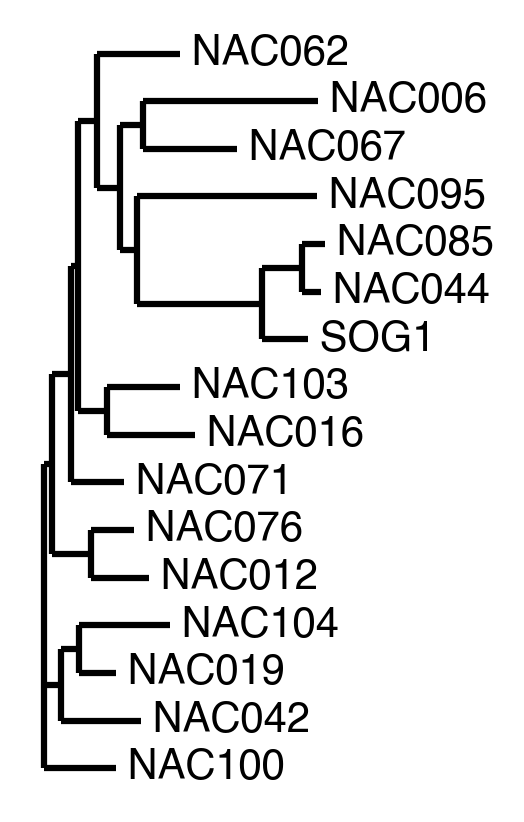

In [207]:
plot_next_to_tree(AD_tree)

In [208]:
activities_aligned_df

,0,1,2,3,4,5,6,7,8,9,...,747,748,749,750,751,752,753,754,755,756
name,,,,,,,,,,,,,,,,,,,,,
NAC006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAC012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAC016,1342.120962,1341.455838,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1571.038690,1485.501960,1397.643184,1318.340095,1258.468419,1226.354197
NAC019,467.518707,469.042619,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAC042,825.139339,825.139339,825.139339,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAC044,580.789660,580.712488,NaN,NaN,NaN,580.492543,579.980442,578.926024,576.983282,573.780242,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAC062,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,923.196806,869.662581,818.962678,776.02978,743.503527,721.456921,708.084979,700.845380,697.385134,696.060576
NAC067,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAC071,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [213]:
activities_aligned_df_normalized = activities_aligned_df / activities_aligned_df.max(numeric_only=True).max()
activities_aligned_df_normalized

,0,1,2,3,4,5,6,7,8,9,...,747,748,749,750,751,752,753,754,755,756
name,,,,,,,,,,,,,,,,,,,,,
NAC006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAC012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAC016,0.298598,0.298450,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.349528,0.330498,0.310951,0.293307,0.279987,0.272842
NAC019,0.104015,0.104354,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAC042,0.183579,0.183579,0.183579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAC044,0.129215,0.129198,NaN,NaN,NaN,0.129149,0.129035,0.128801,0.128368,0.127656,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAC062,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.205395,0.193484,0.182205,0.172653,0.165416,0.160511,0.157536,0.155926,0.155156,0.154861
NAC067,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAC071,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


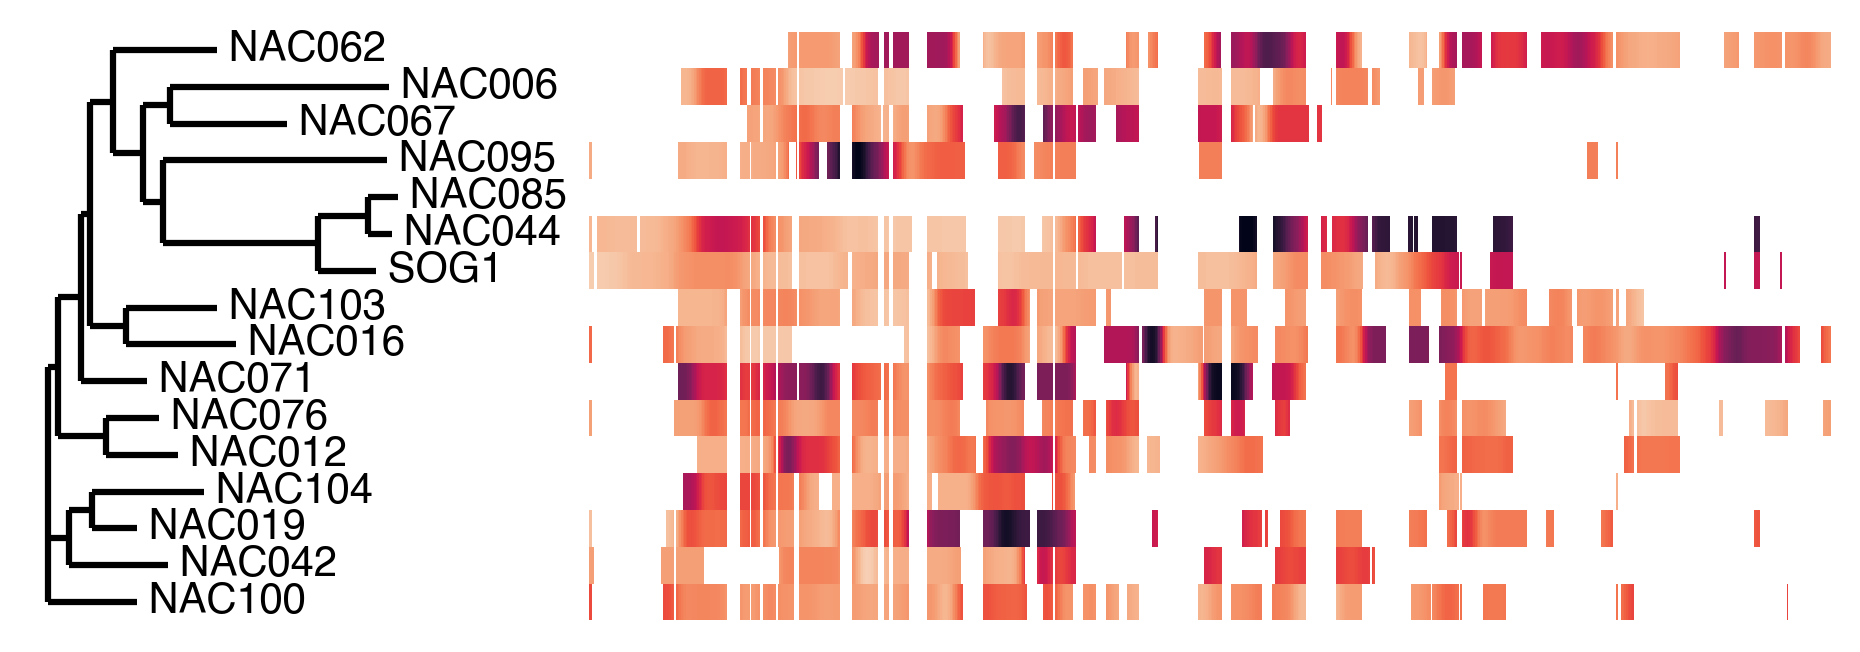

In [401]:
fig = plt.figure(figsize=(6,2), dpi = 300)
spec = fig.add_gridspec(16,2, width_ratios = [1.1, 3])

ax0 = fig.add_subplot(spec[:, 0])

# Draw tree
# Draw the first tree in the first subplot
Phylo.draw(AD_tree, do_show=False, axes=ax0, show_confidence=False)  # Pass axes to the draw function
sns.despine(ax=ax0, left = True, bottom = True)  # Remove the top and right spines
ax0.set_xticks([])
ax0.set_yticks([])
ax0.set_xlabel("")
ax0.set_ylabel("")
ax0.set_ylim(0.5,16.5)


for i in np.arange(16):
    label = name_order[len(name_order) - 1 -i]
    ax_i = fig.add_subplot(spec[i, 1])
    ax_i.imshow([activities_aligned_df_normalized.loc[label]], 
                aspect="auto", interpolation="none", 
                extent=[0, 757, 0, 1], 
                cmap = "rocket_r", 
                vmin = 0, 
                vmax = 0.95)
    ax_i.set_xticks([])
    ax_i.set_yticks([])
    ax_i.set_ylabel("")

sns.despine(left = True, bottom = True)
plt.tight_layout(pad = 0)
plt.savefig("../output/figures/conservation/nac_family/full_aligned.png", bbox_inches='tight')


# 3. Only aligning on DBD

In [282]:
nac_seqs["DBD_seq"] = nac_seqs[1].str.extract("(G..F.P)")
nac_seqs["DBD_pos"] = [seq.find(pat) for seq, pat in zip(nac_seqs[1], nac_seqs["DBD_seq"])]
nac_seqs["len_past_dom"] = nac_seqs[1].str.len() - nac_seqs["DBD_pos"]
#nac_seqs["len_pre_dom"] = 
nac_seqs["len"] = nac_seqs[1].str.len()
nac_seqs

,0,1,name,uniprotID,Other,search_term,DBD_seq,DBD_pos,len_past_dom,len
0,006|Q9LR74|,MKILPVGSRFCPTDLGLVRLYLRNKVERNQSSFITTMDIHQDYPWL...,NAC006,Q9LR74,Q9LR74,Basic6\.,GSRFCP,6,275,281
1,012|Q9LPI7|,MADNKVNLSINGQSKVPPGFRFHPTEEELLHYYLRKKVNSQKIDLD...,NAC012,Q9LPI7,Q9LPI7,Basic12\.,GFRFHP,18,340,358
2,016|A4FVP|,MVDSSRDSCFKAGKFSAPGFRFHPTDEELVVYYLKRKICCKKLRVN...,NAC016,A4FVP,A4FVP,Basic16\.,GFRFHP,18,546,564
3,019|Q9C932|,MGIQETDPLTQLSLPPGFRFYPTDEELMVQYLCRKAAGYDFSLQLI...,NAC019,Q9C932,Q9C932,Basic19\.,GFRFYP,16,301,317
4,042|Q9SK55|JUNGBRUNNEN|,MSGEGNLGKDHEEENEAPLPGFRFHPTDEELLGYYLRRKVENKTIK...,NAC042,Q9SK55,Q9SK55,Basic42\.,GFRFHP,20,255,275
5,044|F4J4R5|,MARAWIVDGRGIAAKVKNASLSSALQIQDCGAHIKCPNCTYRIDNS...,NAC044,F4J4R5,F4J4R5,Basic44\.,GVKFEP,57,309,366
6,062|Q9SCK6|,MNQNLHVLSMDSLPVGLRFRPTDEELIRYYLRRKINGHDDDVKAIR...,NAC062,Q9SCK6,Q9SCK6,Basic62\.,GLRFRP,15,454,469
7,067|O82593|,MMKDPTGYRFSPTGEEVINHYLKNKILGKTWLVDEAISEINILNHK...,NAC067,O82593,O82593,Basic67\.,GYRFSP,6,296,302
8,071|O49697|,MGSSCLPPGFRFHPTDEELIGYYLSRKIEGLEIELEVIPVIDLYKF...,NAC071,O49697,O49697,Basic71\.,GFRFHP,8,254,262
9,076|O65508|,MESVDQSCSVPPGFRFHPTDEELVGYYLRKKVASQKIDLDVIRDID...,NAC076,O65508,O65508,Basic76\.,GFRFHP,12,365,377


In [283]:
# One with 60 residues prior to DBD
max(nac_seqs["DBD_pos"])

60

In [284]:
# One with 546 residues post DBD
max(nac_seqs["len_past_dom"])

546

In [285]:
# Num positions
60 + 546

606

In [286]:
pd.DataFrame(activity_dict["SOG1"]).T

,0,1,2,3,4,5,6,7,8,9,...,439,440,441,442,443,444,445,446,447,448
0,349.854653,349.934281,350.161224,350.689619,351.777587,353.782144,357.087099,361.963034,368.407009,376.036041,...,2219.761865,2220.128347,2220.446933,2220.708784,2220.904217,2221.036683,2221.117028,2221.160527,2221.181318,2221.189276


In [287]:
activity_dict_normalized = {}
for key in activity_dict.keys():
    activity_dict_normalized[key] = np.array(activity_dict[key]) / activities_aligned_df.max(numeric_only=True).max()

(-60.0, 546.0)

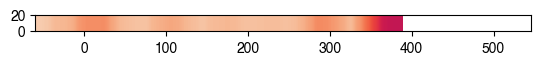

In [289]:
plt.imshow(pd.DataFrame(activity_dict_normalized["SOG1"]).T,
           interpolation=None, 
           cmap = "rocket_r", 
           vmin = 0, vmax = 0.95, 
           extent = [-60, 389, 0, 20])
plt.xlim(-60, 546)

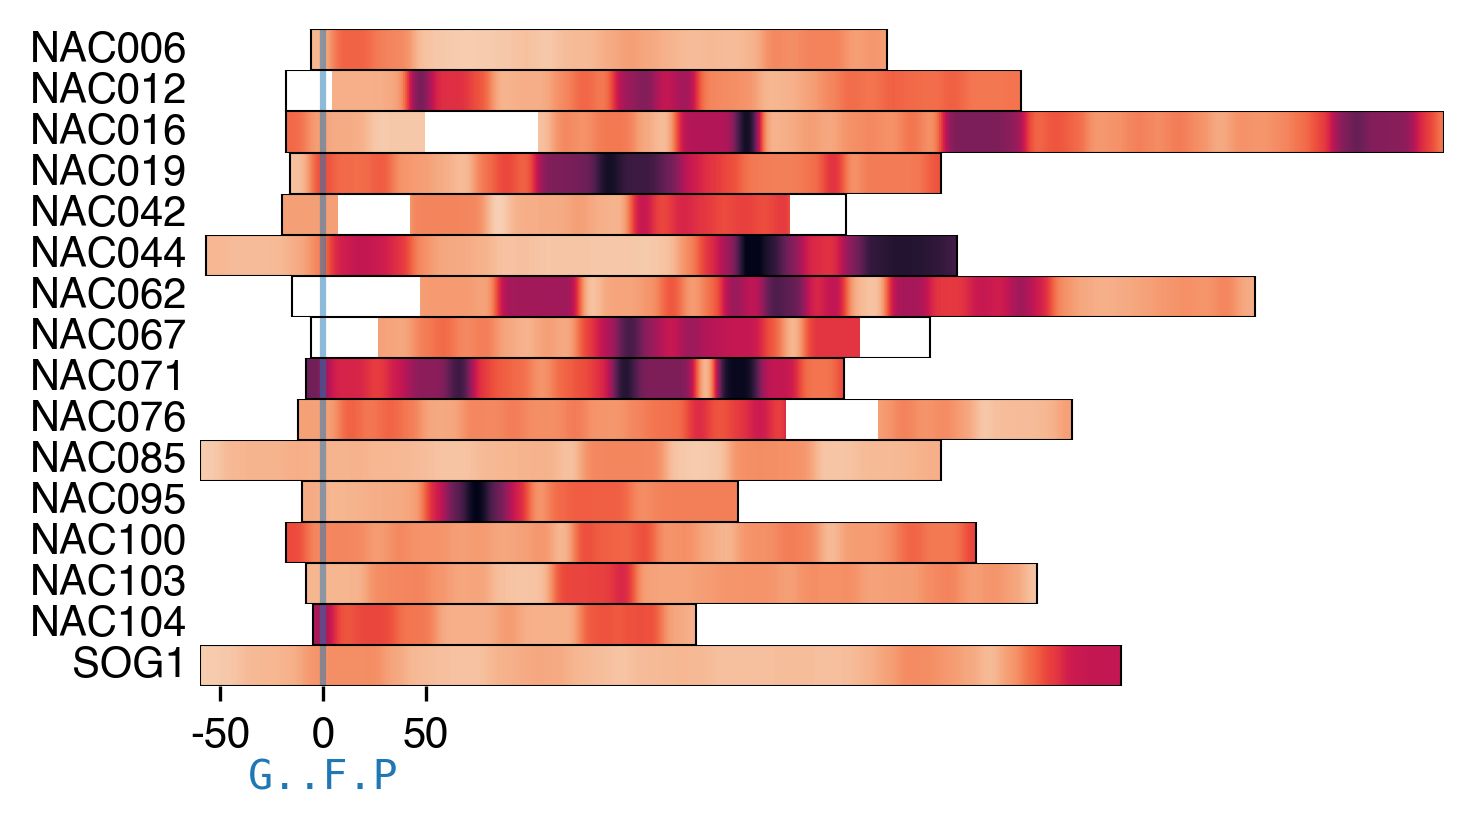

In [347]:
fig, axs = plt.subplots(16,1, sharex = True, figsize = (5, 2.5), dpi = 300)

for i in nac_seqs.index:
    name = nac_seqs["name"].iloc[i]
    start = -1 * nac_seqs["DBD_pos"].iloc[i]
    end = nac_seqs["len_past_dom"].iloc[i]

    axs[i].imshow(pd.DataFrame(activity_dict_normalized[name]).T,
           interpolation=None, 
           cmap = "rocket_r", 
           vmin = 0, vmax = 0.95, 
           extent = [start, end, 0, 20])
    axs[i].set_xlim(-60, 546)
    axs[i].set_xticks([])
    axs[i].set_yticks([])
    axs[i].axvline(0, alpha = 0.5)
    axs[i].set_ylabel(name, rotation = 0, va = 'center', labelpad = 3, ha = "right")
    
    axs[i].axvline(start, color = "black", lw = 0.5)
    axs[i].axvline(end, color = "black", lw = 0.5)

    axs[i].plot((start, end), (20, 20), 'k-',linewidth=0.5)
    axs[i].plot((start, end), (0, 0), 'k-',linewidth=0.5)

axs[-1].set_xticks([-50, 0, 50])
axs[-1].set_xticklabels([-50, 0, 50])
axs[-1].text(x = 0, y = -35, va = "top", ha = "center", s = "G..F.P", color = sns.color_palette("tab10")[0], font = 'monospace')

sns.despine(left = True, bottom = True)
plt.tight_layout(pad = 0)

In [350]:
nac_seqs = nac_seqs.set_index("name")
nac_seqs

,0,1,uniprotID,Other,search_term,DBD_seq,DBD_pos,len_past_dom,len
name,,,,,,,,,
NAC006,006|Q9LR74|,MKILPVGSRFCPTDLGLVRLYLRNKVERNQSSFITTMDIHQDYPWL...,Q9LR74,Q9LR74,Basic6\.,GSRFCP,6,275,281
NAC012,012|Q9LPI7|,MADNKVNLSINGQSKVPPGFRFHPTEEELLHYYLRKKVNSQKIDLD...,Q9LPI7,Q9LPI7,Basic12\.,GFRFHP,18,340,358
NAC016,016|A4FVP|,MVDSSRDSCFKAGKFSAPGFRFHPTDEELVVYYLKRKICCKKLRVN...,A4FVP,A4FVP,Basic16\.,GFRFHP,18,546,564
NAC019,019|Q9C932|,MGIQETDPLTQLSLPPGFRFYPTDEELMVQYLCRKAAGYDFSLQLI...,Q9C932,Q9C932,Basic19\.,GFRFYP,16,301,317
NAC042,042|Q9SK55|JUNGBRUNNEN|,MSGEGNLGKDHEEENEAPLPGFRFHPTDEELLGYYLRRKVENKTIK...,Q9SK55,Q9SK55,Basic42\.,GFRFHP,20,255,275
NAC044,044|F4J4R5|,MARAWIVDGRGIAAKVKNASLSSALQIQDCGAHIKCPNCTYRIDNS...,F4J4R5,F4J4R5,Basic44\.,GVKFEP,57,309,366
NAC062,062|Q9SCK6|,MNQNLHVLSMDSLPVGLRFRPTDEELIRYYLRRKINGHDDDVKAIR...,Q9SCK6,Q9SCK6,Basic62\.,GLRFRP,15,454,469
NAC067,067|O82593|,MMKDPTGYRFSPTGEEVINHYLKNKILGKTWLVDEAISEINILNHK...,O82593,O82593,Basic67\.,GYRFSP,6,296,302
NAC071,071|O49697|,MGSSCLPPGFRFHPTDEELIGYYLSRKIEGLEIELEVIPVIDLYKF...,O49697,O49697,Basic71\.,GFRFHP,8,254,262


In [375]:
def return_positions(string, substring):
    def return_positions_helper(string, substring, pos, positions):
        window_size = len(substring)
        if len(string) == 0:
            return positions
        if string[:window_size] == substring:
            positions.append(pos)
            string = string[window_size:]
            pos += window_size - 1
        else:
            string = string[1:]
            
        return return_positions_helper(string, substring, pos + 1, positions)

    return return_positions_helper(string, substring, 1, [])

def return_positions_multip_strs(string, substring1, substring2):
    matches_1 = return_positions(string, substring1)
    matches_2 = return_positions(string, substring2)
    return list(set(matches_1).union(set(matches_2)))

In [376]:
nac_seqs

,0,1,uniprotID,Other,search_term,DBD_seq,DBD_pos,len_past_dom,len
name,,,,,,,,,
NAC006,006|Q9LR74|,MKILPVGSRFCPTDLGLVRLYLRNKVERNQSSFITTMDIHQDYPWL...,Q9LR74,Q9LR74,Basic6\.,GSRFCP,6,275,281
NAC012,012|Q9LPI7|,MADNKVNLSINGQSKVPPGFRFHPTEEELLHYYLRKKVNSQKIDLD...,Q9LPI7,Q9LPI7,Basic12\.,GFRFHP,18,340,358
NAC016,016|A4FVP|,MVDSSRDSCFKAGKFSAPGFRFHPTDEELVVYYLKRKICCKKLRVN...,A4FVP,A4FVP,Basic16\.,GFRFHP,18,546,564
NAC019,019|Q9C932|,MGIQETDPLTQLSLPPGFRFYPTDEELMVQYLCRKAAGYDFSLQLI...,Q9C932,Q9C932,Basic19\.,GFRFYP,16,301,317
NAC042,042|Q9SK55|JUNGBRUNNEN|,MSGEGNLGKDHEEENEAPLPGFRFHPTDEELLGYYLRRKVENKTIK...,Q9SK55,Q9SK55,Basic42\.,GFRFHP,20,255,275
NAC044,044|F4J4R5|,MARAWIVDGRGIAAKVKNASLSSALQIQDCGAHIKCPNCTYRIDNS...,F4J4R5,F4J4R5,Basic44\.,GVKFEP,57,309,366
NAC062,062|Q9SCK6|,MNQNLHVLSMDSLPVGLRFRPTDEELIRYYLRRKINGHDDDVKAIR...,Q9SCK6,Q9SCK6,Basic62\.,GLRFRP,15,454,469
NAC067,067|O82593|,MMKDPTGYRFSPTGEEVINHYLKNKILGKTWLVDEAISEINILNHK...,O82593,O82593,Basic67\.,GYRFSP,6,296,302
NAC071,071|O49697|,MGSSCLPPGFRFHPTDEELIGYYLSRKIEGLEIELEVIPVIDLYKF...,O49697,O49697,Basic71\.,GFRFHP,8,254,262


In [381]:
#sog1_orthologs["potential_PS"] = sog1_orthologs["Unnamed: 1"].str.findall("SQ")
nac_seqs["potential_PS"] = [return_positions_multip_strs(seq, "SQ", "TP") for seq in nac_seqs[1]]
nac_seqs_PS = dict(zip(nac_seqs.index, nac_seqs["potential_PS"]))
nac_seqs_PS

{'NAC006': [],
 'NAC012': [147, 70, 40, 234, 267, 254],
 'NAC016': [78, 473, 442, 489, 397],
 'NAC019': [],
 'NAC042': [170],
 'NAC044': [242, 355, 244, 346, 139, 237],
 'NAC062': [256],
 'NAC067': [127],
 'NAC071': [195, 142],
 'NAC076': [304, 34, 308],
 'NAC085': [240, 53, 142],
 'NAC095': [211],
 'NAC100': [291, 317],
 'NAC103': [331, 165],
 'NAC104': [107],
 'SOG1': [356, 423, 237, 430, 270, 372, 436, 244, 249, 350]}

In [385]:
nac_seqs_DBD_adj = dict(zip(nac_seqs.index, nac_seqs["DBD_pos"]))
nac_seqs_DBD_adj

{'NAC006': 6,
 'NAC012': 18,
 'NAC016': 18,
 'NAC019': 16,
 'NAC042': 20,
 'NAC044': 57,
 'NAC062': 15,
 'NAC067': 6,
 'NAC071': 8,
 'NAC076': 12,
 'NAC085': 60,
 'NAC095': 10,
 'NAC100': 18,
 'NAC103': 8,
 'NAC104': 5,
 'SOG1': 60}

In [382]:
name_order

['NAC100',
 'NAC042',
 'NAC019',
 'NAC104',
 'NAC012',
 'NAC076',
 'NAC071',
 'NAC016',
 'NAC103',
 'SOG1',
 'NAC044',
 'NAC085',
 'NAC095',
 'NAC067',
 'NAC006',
 'NAC062']

In [392]:
def plot_one_trace(name, ax, PS = False):
    start = -1 * nac_seqs["DBD_pos"].loc[name]
    end = nac_seqs["len_past_dom"].loc[name]

    ax.imshow(pd.DataFrame(activity_dict_normalized[name]).T,
           interpolation=None, 
           cmap = "rocket_r", 
           vmin = 0, vmax = 0.95, 
           extent = [start, end, 0, 20])
    ax.set_xlim(-60, 546)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axvline(0, alpha = 0.5)
    ax.set_ylabel(name, rotation = 0, va = 'center', labelpad = 3, ha = "right")
    
    ax.axvline(start, color = "black", lw = 0.5)
    ax.axvline(end, color = "black", lw = 0.5)

    ax.plot((start, end), (20, 20), 'k-',linewidth=0.5)
    ax.plot((start, end), (0, 0), 'k-',linewidth=0.5)

    if PS:
        for PS in nac_seqs_PS[name]:
            ax.axvline(PS - nac_seqs_DBD_adj[name], alpha = 0.75, linestyle = 'solid', color = 'yellow', lw = 1)
        

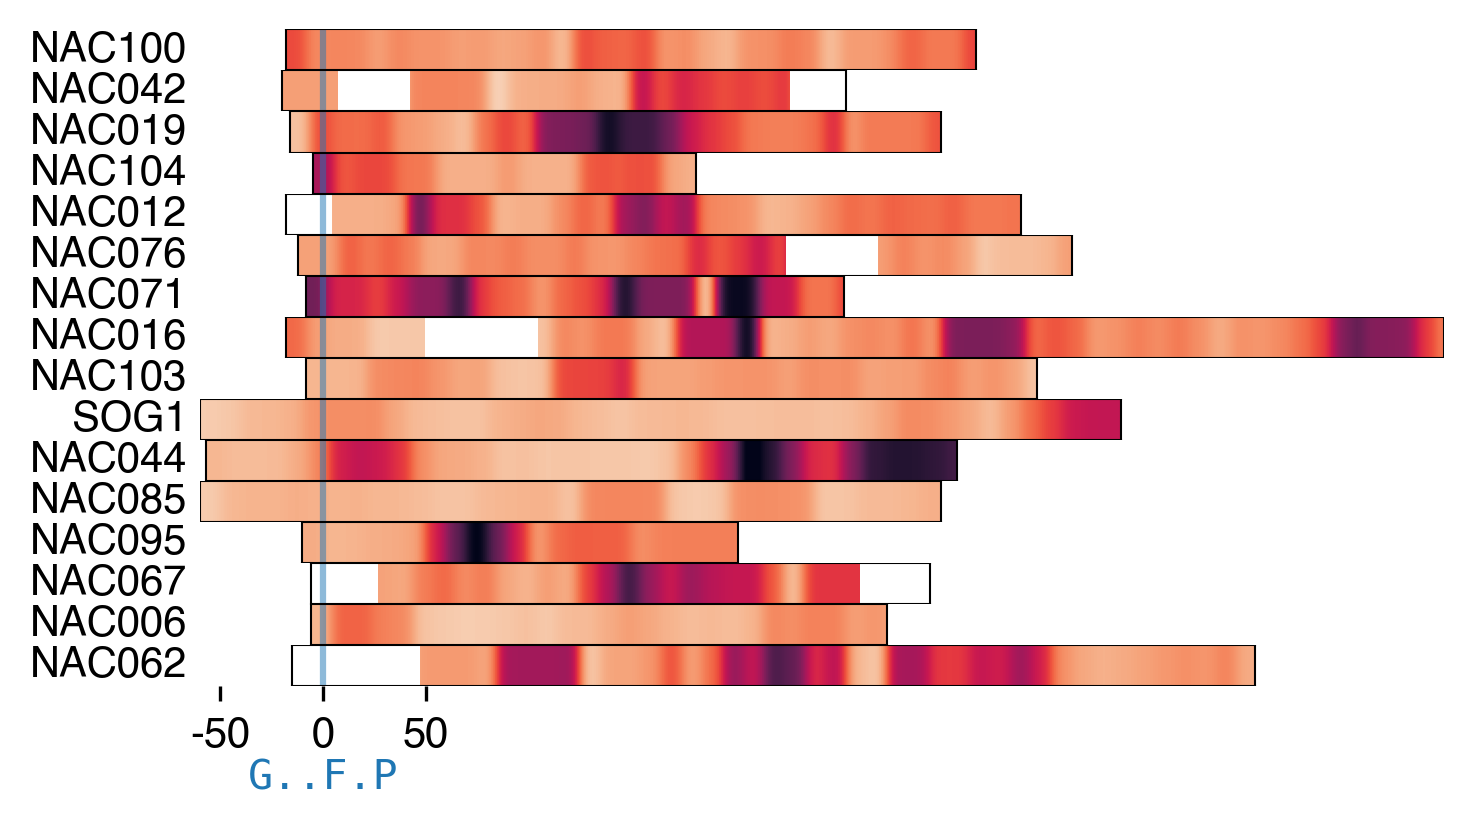

In [394]:
fig, axs = plt.subplots(16,1, sharex = True, figsize = (5, 2.5), dpi = 300)

for name, i in zip(name_order, np.arange(len(nac_seqs))):
    plot_one_trace(name, axs[i], PS = False)
    
axs[-1].set_xticks([-50, 0, 50])
axs[-1].set_xticklabels([-50, 0, 50])
axs[-1].text(x = 0, y = -35, va = "top", ha = "center", s = "G..F.P", color = sns.color_palette("tab10")[0], font = 'monospace')

sns.despine(left = True, bottom = True)
plt.tight_layout(pad = 0)

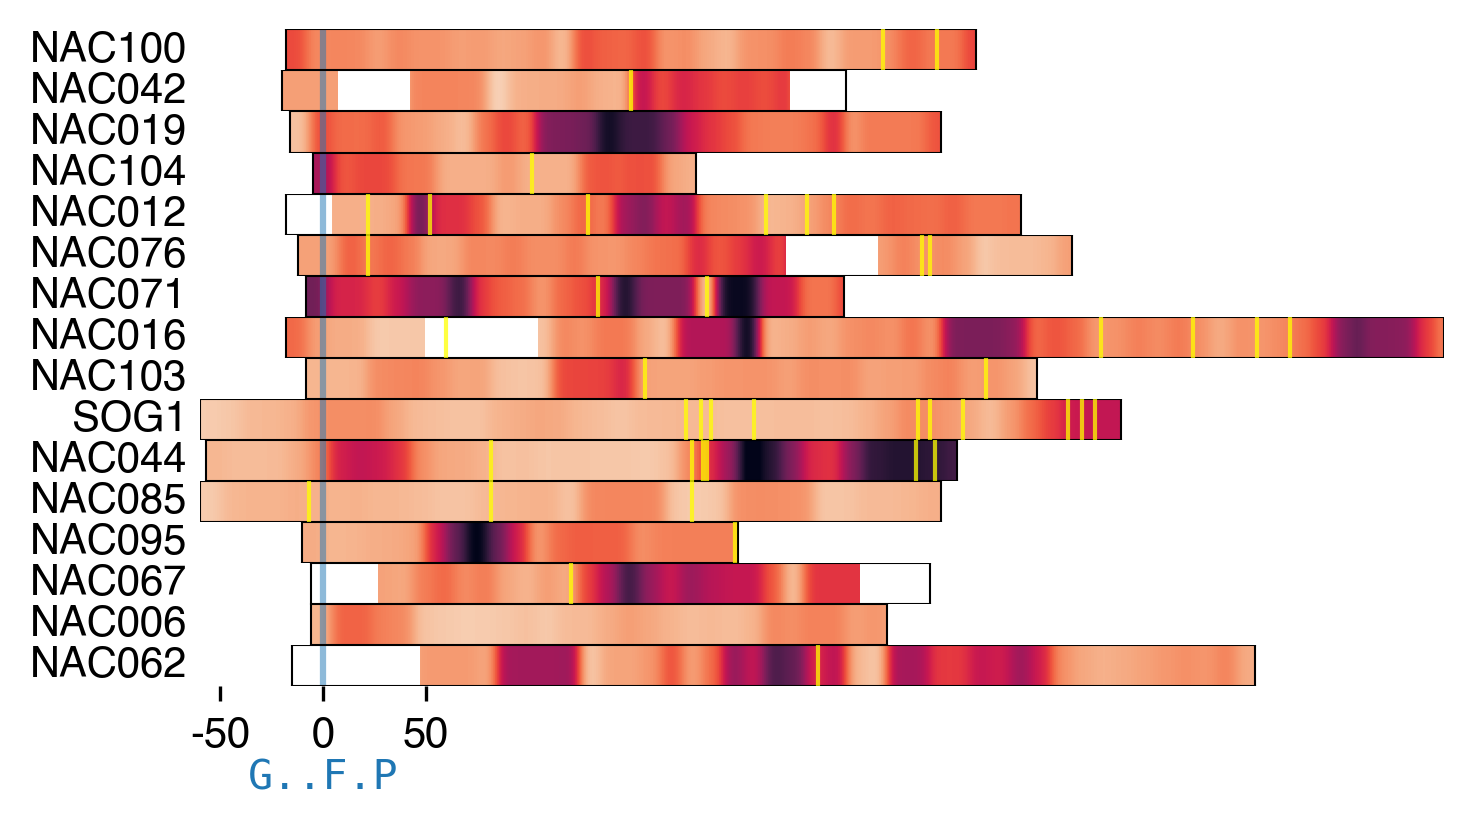

In [395]:
fig, axs = plt.subplots(16,1, sharex = True, figsize = (5, 2.5), dpi = 300)

for name, i in zip(name_order, np.arange(len(nac_seqs))):
    plot_one_trace(name, axs[i], PS = True)
    
axs[-1].set_xticks([-50, 0, 50])
axs[-1].set_xticklabels([-50, 0, 50])
axs[-1].text(x = 0, y = -35, va = "top", ha = "center", s = "G..F.P", color = sns.color_palette("tab10")[0], font = 'monospace')

sns.despine(left = True, bottom = True)
plt.tight_layout(pad = 0)

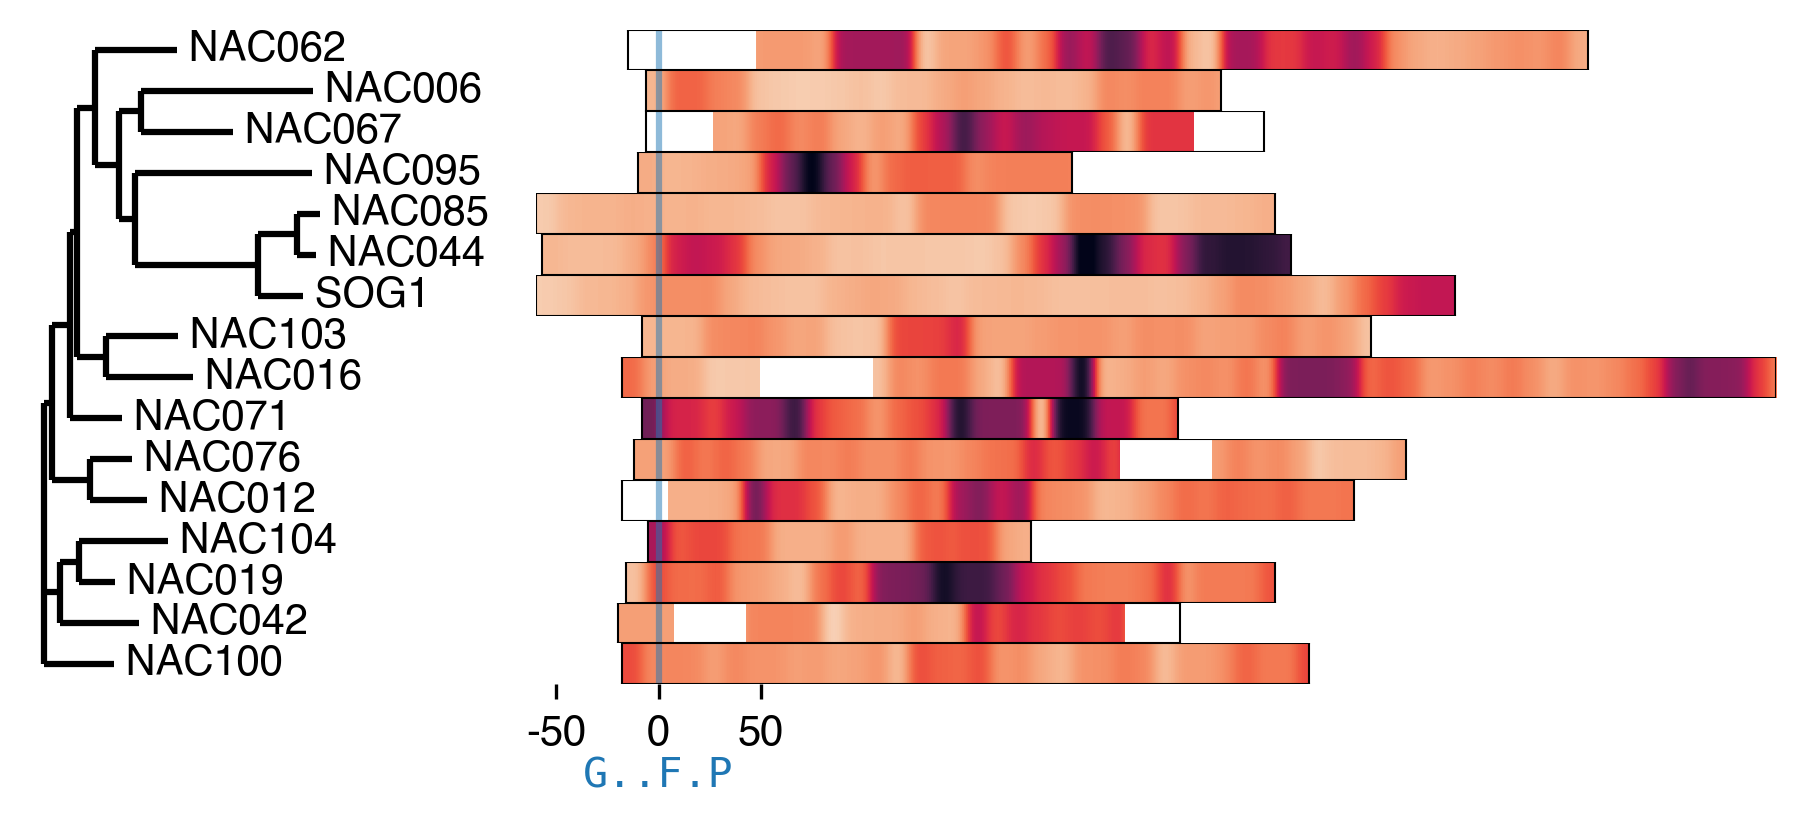

In [399]:
fig = plt.figure(figsize=(6,2.5
                         ), dpi = 300)
spec = fig.add_gridspec(16,2, width_ratios = [0.8, 3])

ax0 = fig.add_subplot(spec[:, 0])

# Draw tree
# Draw the first tree in the first subplot
Phylo.draw(AD_tree, do_show=False, axes=ax0, show_confidence=False)  # Pass axes to the draw function
sns.despine(ax=ax0, left = True, bottom = True)  # Remove the top and right spines
ax0.set_xticks([])
ax0.set_yticks([])
#axs[0].set_title("Tree 1")  # Set title for the first tree
ax0.set_xlabel("")
ax0.set_ylabel("")
ax0.set_ylim(0.5,16.5)

for i in range(len(name_order)):
    ax_i = fig.add_subplot(spec[i, 1])
    plot_one_trace(name_order[len(name_order) - i - 1], ax_i)
    ax_i.set_ylabel("")

# ax_i.set_xticks([-100, 0, 100])
# ax_i.set_xticklabels([-100, 0, 100])
        
#ax_i.text(x = 0, y = -30, va = "top", ha = "center", s = motif_align, color = sns.color_palette("tab10")[0], font = 'monospace')

ax_i.set_xticks([-50, 0, 50])
ax_i.set_xticklabels([-50, 0, 50])
ax_i.text(x = 0, y = -35, va = "top", ha = "center", s = "G..F.P", color = sns.color_palette("tab10")[0], font = 'monospace')
plt.tight_layout(pad = 0)
sns.despine(left = True, bottom = True)


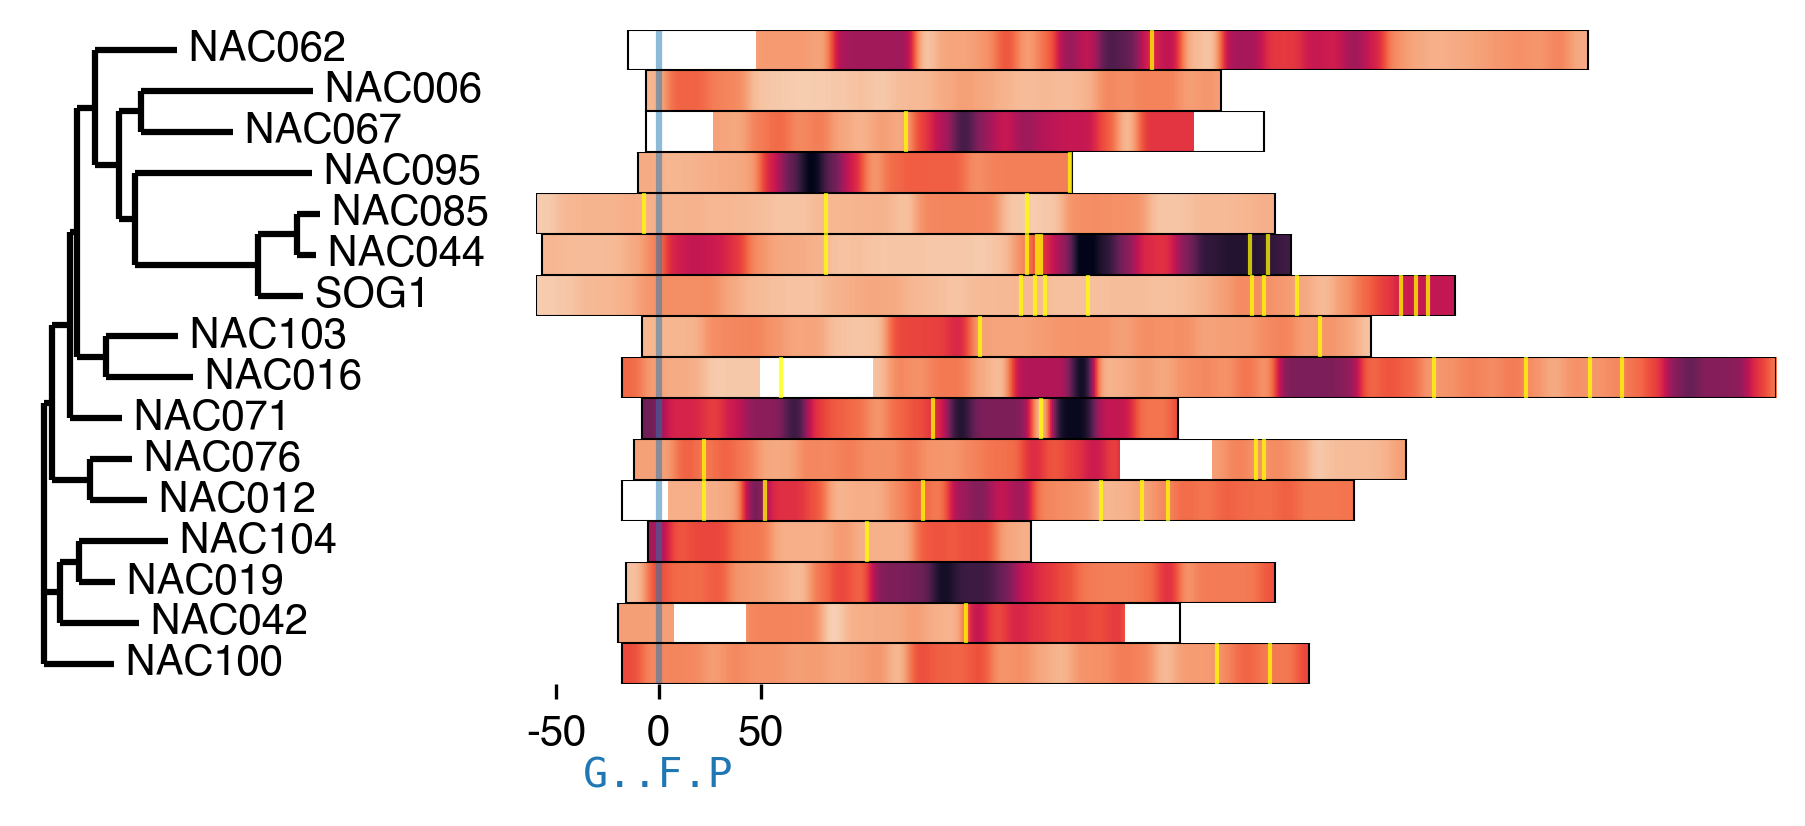

In [400]:
fig = plt.figure(figsize=(6,2.5
                         ), dpi = 300)
spec = fig.add_gridspec(16,2, width_ratios = [0.8, 3])

ax0 = fig.add_subplot(spec[:, 0])

# Draw tree
# Draw the first tree in the first subplot
Phylo.draw(AD_tree, do_show=False, axes=ax0, show_confidence=False)  # Pass axes to the draw function
sns.despine(ax=ax0, left = True, bottom = True)  # Remove the top and right spines
ax0.set_xticks([])
ax0.set_yticks([])
#axs[0].set_title("Tree 1")  # Set title for the first tree
ax0.set_xlabel("")
ax0.set_ylabel("")
ax0.set_ylim(0.5,16.5)

for i in range(len(name_order)):
    ax_i = fig.add_subplot(spec[i, 1])
    plot_one_trace(name_order[len(name_order) - i - 1], ax_i, PS = True)
    ax_i.set_ylabel("")

# ax_i.set_xticks([-100, 0, 100])
# ax_i.set_xticklabels([-100, 0, 100])
        
#ax_i.text(x = 0, y = -30, va = "top", ha = "center", s = motif_align, color = sns.color_palette("tab10")[0], font = 'monospace')

ax_i.set_xticks([-50, 0, 50])
ax_i.set_xticklabels([-50, 0, 50])
ax_i.text(x = 0, y = -35, va = "top", ha = "center", s = "G..F.P", color = sns.color_palette("tab10")[0], font = 'monospace')
plt.tight_layout(pad = 0)
sns.despine(left = True, bottom = True)

plt.savefig("../output/figures/conservation/nac_family/DBD_aligned.png", bbox_inches='tight')
